# General Information
This analysis notebook is purposed with running the hierarchical clustering analysis (HCA) on the Pokemon type x word and Pokemon generation x word matrices. It also contains the code used to originally pull the data from the PokeAPI and the two exploratory plots used in MI2. The necessary data files can be found in DS-4002-group-01/project1/DATA/ in the github: `pokedex.csv`, `pokemon_type-word_matrix.csv`, and `pokemon_gen-word_matrix.csv` (the two matrices are created by running `pokemon_data_cleaning_for_hca.Rmd` first). This notebook should be run from inside the SCRIPTS folder so the relative file paths work. It requires the following packages: `requests`, `pandas`, `numpy`, `matplotlib`, `scipy`, and `scikit-learn`. To install these packages use the `pip install package_name` syntax.

# Loading Packages

In [1]:
# Loading packages
import requests # for pulling data from the PokeAPI
import pandas as pd # for general data wrangling (data frames, reading and writing CSVs)
import time # for pausing between API requests so we don't overload the PokeAPI
import matplotlib.pyplot as plt # for all plotting (exploratory plots, dendrograms, silhouette plots)
import numpy as np # for matrix math (e.g., normalizing rows)
from scipy.cluster.hierarchy import fcluster # for cutting the HCA tree into a set number of clusters
from scipy.spatial.distance import pdist, squareform # for calculating cosine distances and converting them into a square table
from sklearn.metrics import silhouette_samples # for calculating silhouette scores to evaluate how well separated the clusters are
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet # for building the HCA tree, plotting it, and checking how well it fits the original distances

# Data Acquisition
This cell pulls every Pokemon species from the PokeAPI and saves it as `pokedex.csv`. It is wrapped in triple quotes so it doesn't run by default (the CSV already exists in the DATA folder).

In [2]:
"""
ONLY RUN THIS ONCE PER SESSION
    - Loading in Data so dont want to make too many requests to the API
    - Use df to see whats loaded 
    - This was used to make the CSV file for the project, uncomment if you need additional data
      (to run it, remove the triple quotes at the very start and end of this cell)

BASE = "https://pokeapi.co/api/v2" # base URL that every PokeAPI request builds on

# Making the request
# Requesting the list of all 1,025 species (Gens I-IX); this only returns each species' name and a URL to its full data
resp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})
species_list = resp.json()["results"]

rows = [] # will hold one dictionary per pokemon, and each dictionary becomes one row of the final data frame
for s in species_list:
    data = requests.get(s["url"]).json() # pulling the full species data (entries, genus, color, generation)
    time.sleep(0.1) # short pause between requests so we are not hammering the API
    # Grabbing the pokedex entry 
    # Takes the FIRST English entry; PokeAPI orders entries by game version, so this is the entry from the pokemon's debut game
    # Also replaces the newline and page-break characters the games use for line breaks with regular spaces
    entry = next(
        (f["flavor_text"].replace("\n", " ").replace("\f", " ")
         for f in data["flavor_text_entries"]
         if f["language"]["name"] == "en"),
        None, # returns None if the pokemon has no English entry
    )

    # Grabbing the English genus (e.g., "Seed Pokémon") the same way; None if no English version exists
    genus = next(
        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),
        None,
    )

    # Grabbing typing, which lives on a separate endpoint (pokemon instead of pokemon-species)
    type_1, type_2 = None, None # defaults in case the request below fails
    try:
        pk = requests.get(f"{BASE}/pokemon/{s['name']}").json()
        types = sorted(pk["types"], key=lambda t: t["slot"]) # sorting by slot so the primary type always comes first
        type_1 = types[0]["type"]["name"] if len(types) > 0 else None # primary type
        type_2 = types[1]["type"]["name"] if len(types) > 1 else None # secondary type (stays None for single-type pokemon)
    except Exception:
        pass # form-varying pokemon (e.g., deoxys, aegislash) have no entry under the bare species name, so their types stay blank (these get filled in during the R cleaning script)

    # Adding this pokemon's information as a new row
    rows.append({
        "id": data["id"],
        "name": data["name"],
        "genus": genus,
        "type_1": type_1,
        "type_2": type_2,
        "color": data["color"]["name"],
        "generation": data["generation"]["name"],
        "pokedex_entry": entry,
    })

# Converting the rows into a data frame, ordering it by pokedex number, and saving it as the project CSV
df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
print(df.head()) # quick check of the first few rows
df.to_csv("pokedex.csv", index=False)
"""

'\nONLY RUN THIS ONCE PER SESSION\n    - Loading in Data so dont want to make too many requests to the API\n    - Use df to see whats loaded \n    - This was used to make the CSV file for the project, uncomment if you need additional data\n\nBASE = "https://pokeapi.co/api/v2"\n\n# Making the request\nresp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})\nspecies_list = resp.json()["results"]\n\nrows = []\nfor s in species_list:\n    data = requests.get(s["url"]).json()\n    time.sleep(0.1)\n    # Grabbing the pokedex entry \n    entry = next(\n        (f["flavor_text"].replace("\n", " ").replace("\x0c", " ")\n         for f in data["flavor_text_entries"]\n         if f["language"]["name"] == "en"),\n        None,\n    )\n\n    genus = next(\n        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),\n        None,\n    )\n\n    type_1, type_2 = None, None\n    try:\n        pk = requests.get(f"{BASE}/pokemon/{s[\'name\']}").json()\n        types = s

# Loading Data

In [3]:
# Loading the pokedex data (the relative path assumes this notebook is being run from inside the SCRIPTS folder)
csv_files = [
    "../DATA/pokedex.csv",
]

df = pd.read_csv(csv_files[0]) # reading in the first (and only) file in the list
df # visualizing

,id,name,genus,type_1,type_2,color,generation,pokedex_entry
0,1,bulbasaur,Seed Pokémon,grass,poison,green,generation-i,A strange seed was planted on its back at birt...
1,2,ivysaur,Seed Pokémon,grass,poison,green,generation-i,"When the bulb on its back grows large, it appe..."
2,3,venusaur,Seed Pokémon,grass,poison,green,generation-i,The plant blooms when it is absorbing solar en...
3,4,charmander,Lizard Pokémon,fire,NaN,red,generation-i,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,Flame Pokémon,fire,NaN,red,generation-i,"When it swings its burning tail, it elevates t..."
...,...,...,...,...,...,...,...,...
1020,1021,raging-bolt,Paradox Pokémon,electric,dragon,yellow,generation-ix,It's said to incinerate everything around it w...
1021,1022,iron-boulder,Paradox Pokémon,rock,psychic,gray,generation-ix,It resembles a Pokémon described in a dubious ...
1022,1023,iron-crown,Paradox Pokémon,steel,psychic,blue,generation-ix,It resembles a mysterious object introduced in...
1023,1024,terapagos,Tera Pokémon,normal,NaN,blue,generation-ix,Terapagos protects itself using its power to t...


# Exploratory Plots
## Figure 1: Pokemon count by type (primary vs. secondary slot)

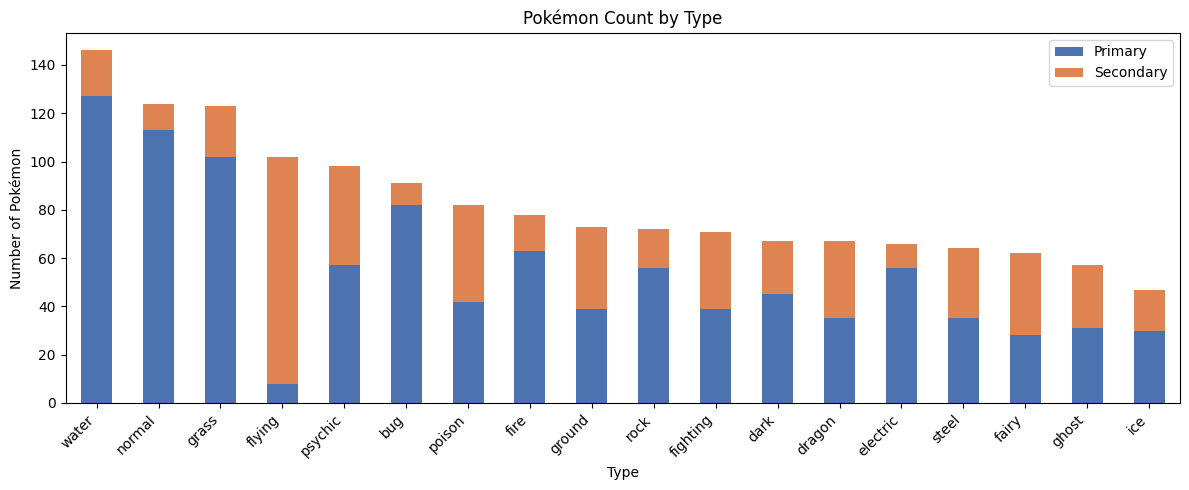

Missing type_1: 37


In [4]:
# Counting how many pokemon have each type in the primary slot vs. the secondary slot
type_counts = pd.DataFrame({
    "Primary": df["type_1"].value_counts(),
    "Secondary": df["type_2"].value_counts(),
}).fillna(0) # a type that never shows up in one of the slots gets a count of 0 instead of NaN

# Ordering types from most to least total pokemon (primary + secondary) so the bars go tallest to shortest
type_counts = type_counts.loc[
    type_counts.sum(axis=1).sort_values(ascending=False).index
]

# Creating a stacked bar chart (primary count on the bottom, secondary count stacked on top)
ax = type_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#4C72B0", "#DD8452"] # blue for primary, orange for secondary
)

# Adding labels
ax.set_title("Pokémon Count by Type")
ax.set_xlabel("Type")
ax.set_ylabel("Number of Pokémon")

plt.xticks(rotation=45, ha="right") # angling the type names so they don't overlap
plt.tight_layout() # keeping labels from getting cut off

# Save the plot
plt.savefig("../OUTPUT/pokemonTypeCounts.png", dpi=300, bbox_inches="tight")

plt.show()

# Checking how many pokemon are missing their primary type (should be the 37 form-varying pokemon that get fixed in the R cleaning script)
print("Missing type_1:", df["type_1"].isna().sum())

## Figure 2: Pokedex entry length by generation

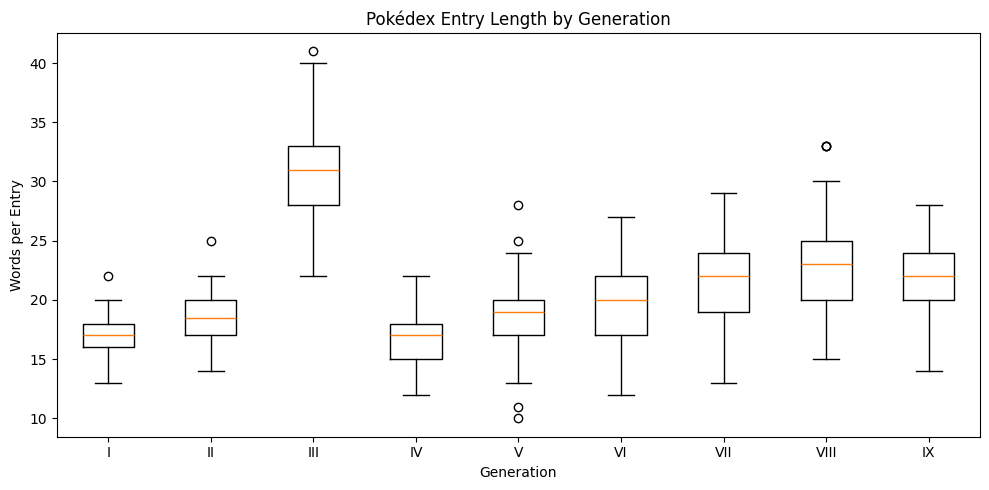

In [5]:
# Dropping any pokemon without an entry and counting the number of words in each entry
entries = df.dropna(subset=["pokedex_entry"]).copy() # making a copy so we don't accidentally edit the original df
entries["entry_words"] = entries["pokedex_entry"].str.split().str.len() # splitting each entry on spaces and counting the pieces

# Order generations
# Sorting generations by their lowest pokedex number so they go I through IX (sorting the names alphabetically would put "generation-ix" before "generation-v")
gen_order = entries.groupby("generation")["id"].min().sort_values().index
labels = [g.split("-")[1].upper() for g in gen_order] # turning "generation-iii" into "III" for the axis labels
data = [entries.loc[entries["generation"] == g, "entry_words"] for g in gen_order] # one set of entry lengths per generation, which is the format boxplot() expects

# Creating a boxplot of entry length for each generation
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data)
ax.set_xticklabels(labels)

# Adding labels
ax.set_title("Pokédex Entry Length by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Words per Entry")
plt.tight_layout() # keeping labels from getting cut off

# Save the plot
plt.savefig("../OUTPUT/pokemonEntryLength.png", dpi=300, bbox_inches="tight")
plt.show()

# Hierarchical Clustering Analysis
## Defining helper functions

In [6]:
# Defining helper functions used throughout the HCA

def l2_normalize(X):
    """Scale each row to unit length 

    Divides every row (one type or generation) by its own length so every row has a length of 1.
    This way a type or generation isn't treated as different just because its TF-IDF values are bigger overall.
    (Cosine distance already ignores length, so this is an extra precaution rather than something that changes results.)
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True) # calculating the length of each row (keepdims keeps it as a column so the division below happens row by row)
    norms[norms == 0] = 1.0 # a row of all 0s has a length of 0, so setting it to 1 avoids dividing by zero
    return X / norms # dividing each row by its own length


def cosine_distances(X):
    """Calculate the cosine distance between every pair of rows.

    Returns the same distances in two formats:
        - d: a flat (condensed) list of every pair's distance, which is the format linkage() and cophenet() need
        - squareform(d): a full rows x rows table, which is the format silhouette_samples() needs
    """
    d = np.clip(pdist(X, metric="cosine"), 0.0, 2.0) # cosine distance can only be between 0 (identical word profiles) and 2; clipping fixes tiny rounding errors (e.g., -0.0000001) that land just outside that range
    return d, squareform(d) # squareform() converts the flat list into the square table


def load_matrix(path, label_col):
    """Load a type-word or generation-word matrix CSV (created in pokemon_data_cleaning_for_hca.Rmd).

    Sets the type/generation names as the row labels and makes sure every word column is numeric,
    so the result is ready to feed straight into the distance calculations.
    """
    df_clean = pd.read_csv(path)
    if label_col in df_clean.columns: # using the type/generation column as the row labels
        df_clean = df_clean.set_index(label_col)
    else:                                  # fall back to first column (in case the label column is named differently)
        df_clean = df_clean.set_index(df_clean.columns[0])
    df_clean.index = df_clean.index.astype(str) # making sure the row labels are text
    return df_clean.apply(pd.to_numeric, errors="coerce").fillna(0.0) # converting every value to a number; anything missing or unconvertible becomes 0 (same as the word not appearing)

## Loading matrices and calculating cosine distances

In [7]:
# Listing the matrices to cluster: each name points to (file path, name of the column that holds the row labels)
# These are the main 150-word matrices created in pokemon_data_cleaning_for_hca.Rmd
MATRICES = {
    "type":       ("../DATA/pokemon_type-word_matrix.csv", "pokemon_type"),
    "generation": ("../DATA/pokemon_gen-word_matrix.csv",  "pokemon_gen"),
}

In [8]:
# Loading both matrices and calculating their cosine distances
mats, dists = {}, {} # will store each matrix and its distances, keyed by "type" or "generation"

for label, (path, label_col) in MATRICES.items():
    m = load_matrix(path, label_col)

    # Removing any type/generation with none of the top 150 words (a row of all 0s), since cosine distance can't compare an empty row
    dead = m.index[m.values.sum(axis=1) == 0].tolist()
    if dead:
        print(f"[{label}] dropping all-zero row(s): {dead}")
        m = m.drop(index=dead)

    X = l2_normalize(m.values.astype(float)) # normalizing each row (see helper functions)
    d, Dsq = cosine_distances(X) # getting both the flat and square versions of the distances
    mats[label], dists[label] = m, (d, Dsq) # saving for the clustering step

    # Checking sizes: type should be 18 rows and generation should be 9 rows, each with 150 word columns
    print(f"[{label}] matrix {m.shape}, condensed dist {d.shape}, square dist {Dsq.shape}")

# Both matrices stacked, indexed by (matrix, label)
df_clean = pd.concat(mats, names=["matrix", "label"])
df_clean # visualizing

[type] matrix (18, 150), condensed dist (153,), square dist (18, 18)
[generation] matrix (9, 150), condensed dist (36,), square dist (9, 9)


silk     honey     cloak     swarm    flower  \
matrix     label                                                               
type       bug              0.034409  0.020926  0.020646  0.020646  0.017906   
           dark             0.000000  0.000000  0.000000  0.000000  0.000000   
           dragon           0.000000  0.000000  0.000000  0.000000  0.000000   
           electric         0.000000  0.000000  0.000000  0.000000  0.000000   
           fairy            0.000000  0.000000  0.000000  0.000000  0.079511   
           fighting         0.000000  0.000000  0.000000  0.000000  0.000000   
           fire             0.000000  0.000000  0.000000  0.000000  0.000000   
           flying           0.000000  0.019190  0.000000  0.000000  0.009852   
           ghost            0.000000  0.000000  0.000000  0.000000  0.000000   
           grass            0.000000  0.000000  0.000000  0.000000  0.023874   
           ground           0.000000  0.000000  0.000000  0.000000  0.000000   
           ice              0.000000  0.000000  0.000000  0.000000  0.000000   
           normal           0.000000  0.000000  0.000000  0.000000  0.000000   
           poison           0.000000  0.000000  0.000000  0.000000  0.000000   
           psychic          0.000000  0.000000  0.000000  0.000000  0.000000   
           rock             0.000000  0.000000  0.000000  0.000000  0.000000   
           steel            0.000000  0.000000  0.000000  0.000000  0.000000   
           water            0.000000  0.000000  0.000000  0.000000  0.000000   
generation generation-i     0.000000  0.000000  0.000000  0.000000  0.000000   
           generation-ii    0.000000  0.000000  0.000000  0.000000  0.000000   
           generation-iii   0.008299  0.000000  0.000000  0.008299  0.001914   
           generation-iv    0.000000  0.024346  0.024346  0.000000  0.003370   
           generation-ix    0.000000  0.000000  0.000000  0.000000  0.001913   
           generation-v     0.000000  0.000000  0.000000  0.000000  0.001200   
           generation-vi    0.000000  0.000000  0.000000  0.000000  0.010591   
           generation-vii   0.000000  0.000000  0.000000  0.000000  0.005695   
           generation-viii  0.000000  0.000000  0.000000  0.000000  0.000000   

                              bubble      host      flap      bark  \
matrix     label                                                     
type       bug              0.015694  0.015694  0.012798  0.010463   
           dark             0.000000  0.000000  0.000000  0.000000   
           dragon           0.000000  0.000000  0.000000  0.000000   
           electric         0.000000  0.000000  0.000000  0.000000   
           fairy            0.000000  0.000000  0.000000  0.000000   
           fighting         0.000000  0.000000  0.000000  0.000000   
           fire             0.000000  0.000000  0.000000  0.012664   
           flying           0.000000  0.000000  0.027385  0.000000   
           ghost            0.000000  0.000000  0.000000  0.000000   
           grass            0.000000  0.009512  0.000000  0.000000   
           ground           0.000000  0.000000  0.000000  0.000000   
           ice              0.000000  0.000000  0.000000  0.000000   
           normal           0.000000  0.000000  0.009881  0.000000   
           poison           0.000000  0.000000  0.000000  0.000000   
           psychic          0.000000  0.000000  0.000000  0.000000   
           rock             0.000000  0.000000  0.000000  0.000000   
           steel            0.000000  0.000000  0.000000  0.000000   
           water            0.017415  0.000000  0.000000  0.000000   
generation generation-i     0.000000  0.015232  0.015232  0.000000   
           generation-ii    0.000000  0.000000  0.000000  0.015528   
           generation-iii   0.000000  0.000000  0.000000  0.000000   
           generation-iv    0.000000  0.000000  0.000000  0.000000   
           generation-ix    0.0

## Running HCA and choosing the number of clusters
**Explaining terminology:**  
Cosine distance = how different two word profiles are based on the direction of their TF-IDF values rather than their size (0 = identical profiles)

Silhouette score = how well a type/generation fits its own cluster compared to the nearest other cluster (ranges from -1 to 1, higher is better); the mean silhouette across all members is used to pick the number of clusters (k)

Cophenetic correlation = how well the dendrogram's merge heights match the original cosine distances (closer to 1 means the tree is a faithful summary of the distances)

In [12]:
LINKAGE = "average"   # Ward needs Euclidean distances; average linkage works with cosine
# (average linkage measures the distance between two clusters as the average distance between all pairs of their members)


def pick_k(Z, Dsq):
    """Mean silhouette for every cut of the tree; returns the best k and all scores.

    Z is the HCA tree from linkage() and Dsq is the square cosine distance table.
    Cuts the tree into every possible number of clusters (k = 2 up to one less than the number of rows),
    scores each cut with the mean silhouette, and returns the k with the highest score
    along with every score (the scores get plotted later).
    """
    n = Dsq.shape[0] # number of types or generations being clustered
    scores = {} # will store k: mean silhouette
    for k in range(2, n): # skipping k = 1 (everything in one cluster) and k = n (everything alone) since neither can be scored
        labels_k = fcluster(Z, t=k, criterion="maxclust") # cutting the tree so there are at most k clusters and labeling each row with its cluster
        if 1 < len(np.unique(labels_k)) < n: # silhouette only works with more than 1 cluster and fewer clusters than rows
            scores[k] = silhouette_samples(Dsq, labels_k, metric="precomputed").mean() # "precomputed" tells it we are giving it distances instead of raw data
    return max(scores, key=scores.get), scores # the k with the highest mean silhouette, plus every score


# Running the HCA for both type and generation
hca = {} # will store all the results for each analysis, keyed by "type" or "generation"

for label, m in mats.items():
    d, Dsq = dists[label]
    Z = linkage(d, method=LINKAGE) # building the tree (what the dendrogram shows) from the cosine distances
    coph_r, _ = cophenet(Z, d) # cophenetic correlation: how well the tree preserves the original distances (closer to 1 is better)
    best_k, sil_scores = pick_k(Z, Dsq) # choosing the number of clusters with the best mean silhouette
    clusters = pd.Series(fcluster(Z, t=best_k, criterion="maxclust"),
                         index=m.index, name="cluster") # labeling each type/generation with its cluster number at the best k
    hca[label] = {"Z": Z, "k": best_k, "clusters": clusters,
                  "sil": sil_scores, "coph": coph_r} # saving everything for the plots below

    # Printing a summary of the results
    print(f"\n[{label}] cophenetic r = {coph_r:.3f} | best k = {best_k} "
          f"(mean silhouette {sil_scores[best_k]:.3f})")
    # Listing each cluster's members and its most characteristic words (the 5 words with the highest average TF-IDF across the cluster's members)
    for c, members in clusters.groupby(clusters):
        top = m.loc[members.index].mean().sort_values(ascending=False).head(5)
        print(f"  cluster {c}: {', '.join(members.index)}")
        print(f"    top words: {', '.join(top[top > 0].index)}") # only showing words with a TF-IDF above 0


[type] cophenetic r = 0.797 | best k = 6 (mean silhouette 0.099)
  cluster 1: fighting, poison
    top words: toxic, punch, gas, muscle, chain
  cluster 2: ice, water
    top words: snow, cold, freeze, breath, frigid
  cluster 3: dark, fire, ghost, ground
    top words: burn, spirit, sand, flame, bone
  cluster 4: normal, psychic, rock, steel
    top words: brain, ago, iron, salt, fossil
  cluster 5: bug, fairy, flying, grass
    top words: flower, scent, emit, flap, honey
  cluster 6: dragon, electric
    top words: electricity, lightning, apple, spark, tusk

[generation] cophenetic r = 0.793 | best k = 2 (mean silhouette 0.028)
  cluster 1: generation-i, generation-ii, generation-iii, generation-iv, generation-ix, generation-v, generation-vi, generation-viii
    top words: emit, magazine, cold, ears, paranormal
  cluster 2: generation-vii
    top words: ultra, balloon, intense, dangerous, wormhole


## Visualizing dendrograms

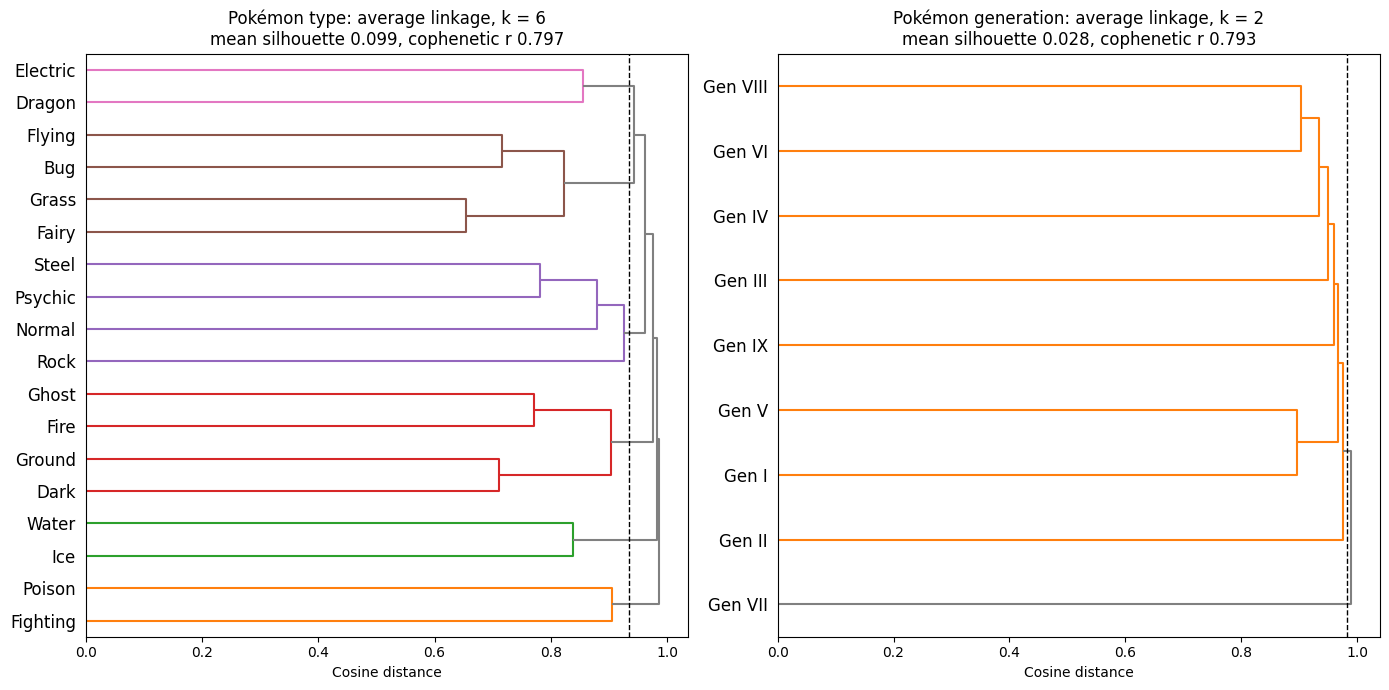

In [13]:
def pretty(label, names):
    """Turn raw row names into clean plot labels.

    label is "type" or "generation" and names are the row names from the matrix,
    e.g., "generation-iii" becomes "Gen III" and "fire" becomes "Fire".
    """
    if label == "generation":
        return ["Gen " + n.split("-")[1].upper() for n in names] # "generation-iii" -> "Gen III"
    return [n.capitalize() for n in names] # "fire" -> "Fire"


# Plotting the type and generation dendrograms side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (label, res) in zip(axes, hca.items()):
    Z, k = res["Z"], res["k"]
    cut = (Z[-k, 2] + Z[-(k - 1), 2]) / 2   # height that leaves exactly k clusters
    # (halfway between the merge that leaves k clusters and the next merge, which would drop it to k - 1)
    dendrogram(Z, labels=pretty(label, mats[label].index), orientation="right",
               color_threshold=cut, above_threshold_color="grey", ax=ax) # branches below the cut are colored by cluster; anything above the cut is grey
    ax.axvline(cut, ls="--", c="k", lw=1) # dashed line showing where the tree was cut
    # Title reports the linkage method, chosen k, its mean silhouette, and the cophenetic correlation
    ax.set_title(f"Pokémon {label}: {LINKAGE} linkage, k = {k}\n"
                 f"mean silhouette {res['sil'][k]:.3f}, cophenetic r {res['coph']:.3f}")
    ax.set_xlabel("Cosine distance")

plt.tight_layout()
plt.show()

## Evaluating silhouette scores

     type  generation
k                    
2   0.042       0.028
3   0.050       0.015
4   0.073       0.023
5   0.088       0.021
6   0.099       0.018
7   0.083       0.019
8   0.074       0.011
9   0.091         NaN
10  0.084         NaN
11  0.061         NaN
12  0.058         NaN
13  0.077         NaN
14  0.074         NaN
15  0.054         NaN
16  0.042         NaN
17  0.022         NaN

[type] per-member silhouette
              cluster  silhouette
pokemon_type                     
fighting            1       0.062
poison              1       0.078
ice                 2       0.088
water               2       0.127
fire                3       0.092
ghost               3       0.104
ground              3       0.119
dark                3       0.138
normal              4      -0.034
rock                4       0.015
psychic             4       0.092
steel               4       0.125
flying              5       0.138
fairy               5       0.142
grass               5       0.

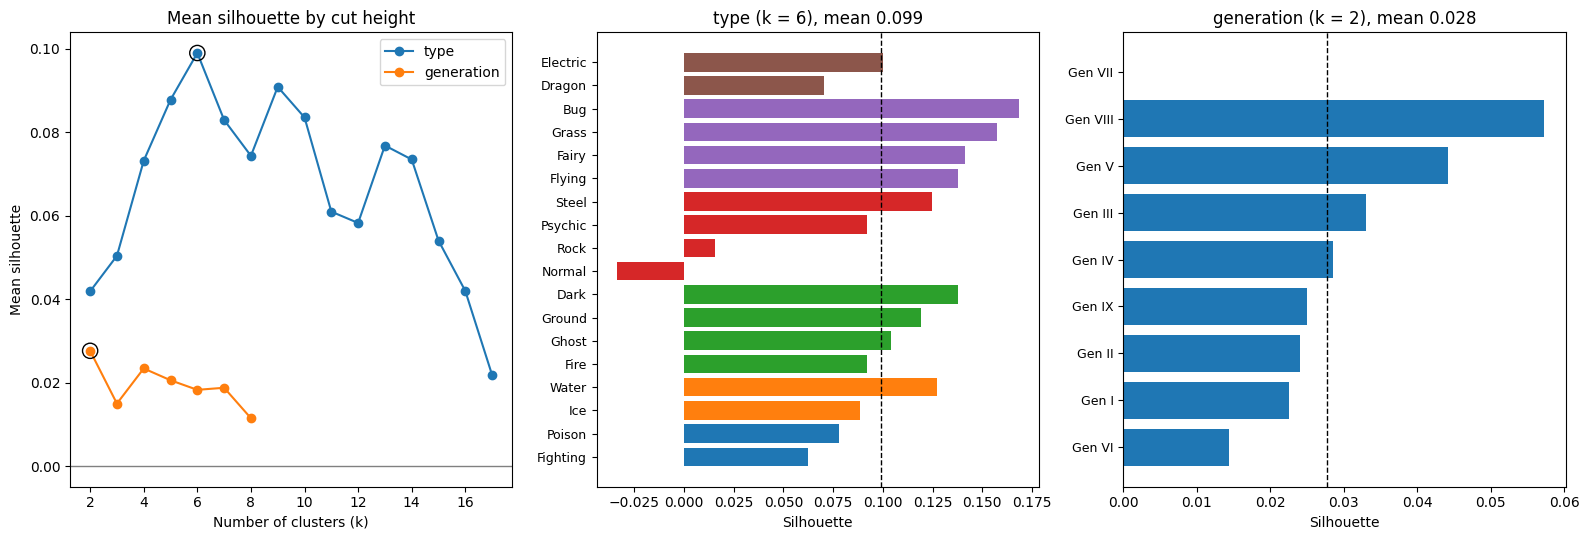

In [ ]:
# Mean silhouette at every cut
# Table with one row per k and one column each for type and generation (generation has fewer rows since it only has 9 members)
sil_table = pd.DataFrame({label: res["sil"] for label, res in hca.items()})
sil_table.index.name = "k"
print(sil_table.round(3))

# Setting up three plots: mean silhouette by k (left), then per-member silhouettes for type (middle) and generation (right)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# how the mean silhouette moves with k
for label, res in hca.items():
    axes[0].plot(list(res["sil"]), list(res["sil"].values()), marker="o", label=label) # one line for type, one for generation
    axes[0].scatter([res["k"]], [res["sil"][res["k"]]], s=120,
                    facecolors="none", edgecolors="k", zorder=3)   # chosen k (circling the point that was picked)
axes[0].axhline(0, c="grey", lw=1) # reference line at 0 (below 0 means members fit other clusters better than their own)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Mean silhouette")
axes[0].set_title("Mean silhouette by cut height")
axes[0].legend()

#per-member silhouette at the chosen k
# (each bar is one type/generation: close to 1 means it fits its cluster well, below 0 means it may fit better in another cluster)
for ax, (label, res) in zip(axes[1:], hca.items()):
    clusters, (d, Dsq) = res["clusters"], dists[label]
    s = pd.Series(silhouette_samples(Dsq, clusters.values, metric="precomputed"),
                  index=clusters.index, name="silhouette") # silhouette score for each individual type/generation
    order = pd.concat([clusters, s], axis=1).sort_values(["cluster", "silhouette"]) # sorting by cluster, then by score, so members of the same cluster sit together

    ax.barh(range(len(order)), order["silhouette"],
            color=plt.cm.tab10((order["cluster"].values - 1) % 10)) # coloring bars by cluster (clusters start at 1, so subtracting 1 starts at the first color)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(pretty(label, order.index), fontsize=9)
    ax.axvline(s.mean(), ls="--", c="k", lw=1) # dashed line at the mean silhouette
    ax.set_xlabel("Silhouette")
    ax.set_title(f"{label} (k = {res['k']}), mean {s.mean():.3f}")

    print(f"\n[{label}] per-member silhouette\n{order.round(3)}") # printing the per-member scores as a table

plt.tight_layout()
plt.show()